In [1]:
import urllib.request
import zipfile
from pathlib import Path
from tqdm import tqdm

from kilosort.utils import DOWNLOADS_DIR

In [10]:
DOWNLOADS_DIR = Path('G:\ACADEMIC') 

# NOTE: Be sure to update this filepath if you want the data downloaded to
#       a specific location.
SAVE_PATH = DOWNLOADS_DIR / '.test_data' / 'ZFM-02370_mini.imec0.ap.short.bin'

SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

In [11]:
class DownloadProgressBar(tqdm):
    """ from https://stackoverflow.com/a/53877507 """
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)

def download_url(url, output_path):
    # Download zip-compressed data file.
    zip_file = Path(output_path).with_suffix('.zip')
    with DownloadProgressBar(unit='B', unit_scale=True,
                             miniters=1, desc=url.split('/')[-1]) as t:
        urllib.request.urlretrieve(url, filename=zip_file, reporthook=t.update_to)
    # Unzip to specified `output_path`.
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(output_path.parent)
    # Remove zip archive after unzipping.
    zip_file.unlink()


## CROPPED DATASET
URL = 'https://osf.io/download/67effd64f74150d8738b7f34/'
download_url(URL, SAVE_PATH)

498MB [00:32, 15.2MB/s]                                                                                                


In [12]:
# Download channel maps for default probes
from kilosort.utils import download_probes
download_probes()

100%|█████████████████████████████████████████████████████████████████████████████████████████| 555/555 [00:00<?, ?B/s]
100%|█████████████████████████████████████████████████████████████████████████████████████| 2.03k/2.03k [00:00<?, ?B/s]
100%|██████████████████████████████████████████████████████████████████████████████| 2.00k/2.00k [00:00<00:00, 126kB/s]


In [23]:
import kilosort
from kilosort import run_kilosort

In [24]:
# NOTE: 'n_chan_bin' is a required setting, and should reflect the total number
#       of channels in the binary file. For information on other available
#       settings, see `kilosort.run_kilosort.default_settings`.
settings = {'filename': SAVE_PATH, 'n_chan_bin': 385}

ops, st, clu, tF, Wall, similar_templates, is_ref, est_contam_rate, kept_spikes = \
    run_kilosort(
        settings=settings, probe_name='NeuroPix1_default.mat',
        # save_preprocessed_copy=True
        )

kilosort.run_kilosort: Kilosort version 4.1.7
kilosort.run_kilosort: Python version 3.11.15
kilosort.run_kilosort: ----------------------------------------
kilosort.run_kilosort: System information:
kilosort.run_kilosort: Windows-10-10.0.26200-SP0 AMD64
kilosort.run_kilosort: Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
kilosort.run_kilosort: Using GPU for PyTorch computations. Specify `device` to change this.
kilosort.run_kilosort: Using CUDA device: NVIDIA GeForce RTX 2050 4.00GB
kilosort.run_kilosort: ----------------------------------------
kilosort.run_kilosort: Sorting [WindowsPath('G:/ACADEMIC/.test_data/ZFM-02370_mini.imec0.ap.short.bin')]
kilosort.run_kilosort: Interpreting binary file as default dtype='int16'. If data was saved in a different format, specify `data_dtype`.
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage before sorting
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:    14.10

In [27]:
# Save the result
from kilosort.io import save_preprocessing,load_ops

save_preprocessing?

Signature:
save_preprocessing(
    filename,
    ops,
    bfile=None,
    bfile_path=None,
    verbose=False,
)
Docstring:
Save a preprocessed copy of data, including drift correction.

Parameters
----------
filename : str or Path-like.
    Path where new file should be saved.
ops : dict.
    Settings and state variables used in sorting. See `kilosort.run_kilosort`.
bfile : BinaryFiltered; optional.
    Binary file loaded as a BinaryFiltered instance, including all variables
    needed for preprocessing (whitening, filtering, and drift correction).
    If specified, `bfile_path` will not be used.
    One of `bfile` or `bfile_path` must be provided.
bfile_path : str or Path-like.
    Path where raw binary data should be loaded from. If `bfile` is given,
    this parameter will not be used.
    One of `bfile` or `bfile_path` must be provided.
File:      e:\anaconda\envs\kilosort\lib\site-packages\kilosort\io.py
Type:      function

In [34]:
results_dir = Path(DOWNLOADS_DIR) / '.test_data' / 'Result1.dat'
results_dir.parent.mkdir(parents=True, exist_ok=True)

save_preprocessing(filename = result_dir,ops = ops, bfile_path=SAVE_PATH)

In [39]:
from pathlib import Path

import numpy as np
import pandas as pd

from kilosort.io import load_ops

# Load the saved Sorting results from the local drive.
results_dir = SAVE_PATH.parent / 'kilosort4'
ops = load_ops(results_dir / 'ops.npy')
camps = pd.read_csv(results_dir / 'cluster_Amplitude.tsv', sep='\t')['Amplitude'].values
contam_pct = pd.read_csv(results_dir / 'cluster_ContamPct.tsv', sep='\t')['ContamPct'].values
chan_map =  np.load(results_dir / 'channel_map.npy')
templates =  np.load(results_dir / 'templates.npy')
chan_best = (templates**2).sum(axis=1).argmax(axis=-1)
chan_best = chan_map[chan_best]
amplitudes = np.load(results_dir / 'amplitudes.npy')
st = np.load(results_dir / 'spike_times.npy')
clu = np.load(results_dir / 'spike_clusters.npy')

fs = ops['fs']
firing_rates = np.unique(clu, return_counts=True)[1] * fs / st.max()
dshift = ops['dshift']

In [42]:
unique_units = np.unique(clu)
N = len(unique_units)
print(f"There are {N} neurons in total.")

random_indices = np.random.randint(0, N, size=2)
selected_units = unique_units[random_indices]
print(f"The indeices of selected two neurons are {random_indices}.")

There are 267 neurons in total.
The indeices of selected two neurons are [  8 228].


The first five sparks for Neuron No. 8  [0.02883333 0.2845     0.3629     0.46593333 0.6865    ]
The first five sparks for Neuron No. 228  [5.46273333 6.85696667 6.9028     6.93106667 6.9479    ]


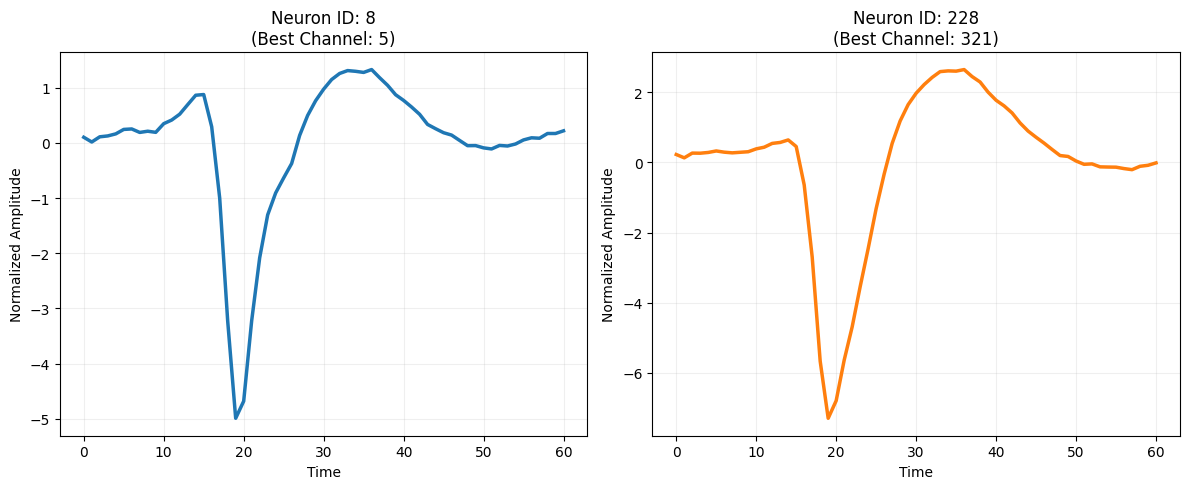

In [44]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import gridspec

plt.figure(figsize=(12, 5))
fs = ops['fs'] 

for i, unit_id in enumerate(selected_units):
    plt.subplot(1, 2, i+1)
    
    unit_template = templates[unit_id]
    
    best_chan_idx = np.argmax((unit_template**2).sum(axis=0))
    
    plt.plot(unit_template[:, best_chan_idx], color=f'C{i}', lw=2.5)
    
    actual_chan = chan_best[unit_id]
    
    plt.title(f"Neuron ID: {unit_id}\n(Best Channel: {actual_chan})")
    plt.xlabel("Time")
    plt.ylabel("Normalized Amplitude")
    plt.grid(alpha=0.2)

    unit_spikes_sec = st[clu == unit_id] / fs
    print(f"The first five sparks for Neuron No. {unit_id}  {unit_spikes_sec[:5]}")

plt.tight_layout()
plt.show()